# IA368-HH

## Retrieval-Augmented Generation (RAG)

Gustavo Freitas Alves

236249


---
## Imports

In [ ]:
!pip -q install sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 22.5 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import copy
import spacy
import faiss
import spacy
import torch
import string
import random
import unicodedata
import collections
import numpy as np
from tqdm import tqdm
from openai import OpenAI
import matplotlib.pyplot as plt
from openai import BadRequestError
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [ ]:
%%capture
!wget https://iirc-dataset.s3.us-west-2.amazonaws.com/context_articles.tar.gz
!wget https://iirc-dataset.s3.us-west-2.amazonaws.com/iirc_test.json
!tar -xf context_articles.tar.gz

---
## Device

Selecionando o device

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


---
## Dados

Obtendo os dados

In [ ]:
test_set = json.load(open("iirc_test.json"))
context_articles = json.load(open("context_articles.json"))

Analisando brevement o conteúdo do *test_set*

In [ ]:
type(test_set), type(context_articles)

(list, dict)

In [ ]:
m = random.randint(0, len(test_set)-1)

In [ ]:
test_set[m].keys()

dict_keys(['questions', 'text', 'links', 'title'])

In [ ]:
test_set[m]

{'questions': [{'answer': {'type': 'span',
    'answer_spans': [{'text': 'Pink Floyd',
      'passage': 'pink floyd',
      'type': 'answer',
      'start': 12,
      'end': 22}]},
   'question': 'Which group that Sanchez is envious of was formed first?',
   'context': [{'text': "Sanchez has several times stated he is envious of his father's era of music, and that the band is influenced by groups of that era, such as Led Zeppelin, Pink Floyd, The Police, Queen, and Thin Lizzy.",
     'passage': 'main',
     'indices': [0, 200]},
    {'text': 'Led Zeppelin were an English rock band formed in London in 1968.',
     'passage': 'Led Zeppelin',
     'indices': [0, 64]},
    {'text': 'Pink Floyd were an English rock band formed in London in 1965.',
     'passage': 'Pink Floyd',
     'indices': [0, 62]},
    {'text': 'The Police were a British rock band formed in London in 1977. ',
     'passage': 'The Police',
     'indices': [0, 62]},
    {'text': 'Queen are a British rock band formed in Lo

---

### Filtragem dos dados

Removo as questões que possuem como *answer_type* o valor None ('none').

Além disso, para quando estou trabalhando no ambiente CPU uso apenas algumas amostras. Isso serve para fazer checagem de funcionamento na CPU e efetivamente executar o processo somente quando estiver na GPU (processo de embedding é mais rápido).

In [ ]:
# removendo questões com resposta none
test_set = [
      item for question in test_set
      for item in question['questions']
      if item['answer']['type'] != 'none'
]

# reduzindo o número de amostras
if device == 'cpu':
  test_set = test_set[:10]
else:
  test_set = test_set[:150] # few-shot de 150 amostras

Quantidade de amostras

In [ ]:
len(test_set)

150

Limpeza dos documentos para remover tags de HTML, PDF, Word e Markdown e espaços extras e \n. Algo semelhante ao que é comentado no artigo. (*Overview of RAG* : *A - Naive RAG*)

Será aplicada nos documentos (*context_articles*).

In [ ]:
def preprocess_text(text: str) -> str:
  """
    Função para limpeza dos artigos
  """

  # Remove tags HTML/XML
  text = re.sub(r"<[^>]+>", " ", text)

  # Remove marcações de Markdown
  text = re.sub(r"!\[.*?\]\(.*?\)", " ", text)   # imagens ![alt](url)
  text = re.sub(r"\[.*?\]\(.*?\)", " ", text)    # links [text](url)
  text = re.sub(r"`{1,3}.*?`{1,3}", " ", text)   # código inline ou blocos
  text = re.sub(r"[*_~#>-]+", " ", text)         # símbolos de formatação (bold, itálico, headers, listas)

  # Remove caracteres de PDF/Word
  text = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", text)  # caracteres de controle
  text = re.sub(r"\ufeff", " ", text)               # ByteOrderMark (char especial invisível)
  text = re.sub(r"\u2028|\u2029", " ", text)        # separadores unicode

  # Remove quebras de linha e espaços extras
  text = re.sub(r"\s+", " ", text)

  return text.strip()

Obtenho apenas os documentos das questões listadas anteriormente e faço a filtragem.

In [ ]:
# lista de links para obter dos documentos (em vez de utilizar tudo)
links = set()
for q in test_set:
  for link in q['question_links']:
    links.add(link.lower())

# geração do dict de documentos com os artigos filtrados
documents = {
    k: preprocess_text(v) for k, v in context_articles.items()
    if k.lower() in links
}

Quantidade de documentos (artigos)

In [ ]:
len(documents)

189

Exemplo de um dos artigos

In [ ]:
m = random.randint(0, len(documents)-1)
for p, doc in enumerate(documents):
  if p == m:
    print(f"Título: {doc}\nConteúdo: {documents[doc]}")

Título: protagonist
Conteúdo: A protagonist () is the main character of a story. The protagonist is at the center of the story, makes the key decisions, and experiences the consequences of those decisions. The protagonist is the primary agent propelling the story forward, and is often the character who faces the most significant obstacles. If a story contains a subplot , or is a narrative made up of several stories, then each subplot may have its own protagonist. The protagonist is the character whose fate is most closely followed by the reader or audience, and who is opposed by the antagonist . The antagonist will provide obstacles and complications and create conflicts that test the protagonist, thus revealing the strengths and weaknesses of the protagonist's character. Ancient Greece.The earliest known examples of a protagonist are found in Ancient Greece . At first, dramatic performances involved merely dancing and recitation by the chorus. Then in Poetics , Aristotle describes how

---
## Chunking (Segmentação)

Processo de *chunking* por sentenças. Tamanho da janela é de 5 sentenças e o *overlap* é  de 2 sentenças. Para esse processo utilizo o modelo pequeno da spaCy.

Carrego o modelo

In [ ]:
nlp = spacy.load("en_core_web_sm")

Definindo variáveis do *chunking*

In [ ]:
CHUNK_SIZE = 5
CHUNK_OVERLAP = 2

Segmentação (*Chunking*)

In [ ]:
def chunk_doc(documents: dict, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP):
    """
      Chunking por sentenças, com janela deslizante (overlap).
    """
    chunked_docs = []

    chunk_words = []
    overlap_words = []

    # varredura nos documentos
    for title, content in tqdm(documents.items()):
      # processamento do texto
      doc = nlp(content)
      # obtenho os textos de cada sentença (ignoro sentenças vazias)
      sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]
      # passos considerando o overlap
      step = chunk_size - overlap
      # varredura pela sentenças para formar os chunks
      for i in range(0, len(sentences), step):
        # chunk
        chunk = " ".join(sentences[i:i+chunk_size])
        # número de palavras por chunk
        chunk_words.append(len(chunk.split()))
        # número de palavras por overleap
        overlap_words.append(len("".join(sentences[i:i+overlap]).split()))

        chunked_docs.append({
            "title": title,
            "chunk_id": i // step,
            "content": chunk
        })

    print(f"\nNúmero de chunks: {len(chunked_docs)}")
    print(f"Média de palavras por chunk: {int(np.mean(chunk_words))}")
    # ignoro o primeiro valor, pois não faz parte do overleap
    print(f"Média de palavras no overlap: {int(np.mean(overlap_words[1:]))}")

    return chunked_docs

Segmentando os documentos

In [ ]:
%%time
chunks_docs = chunk_doc(documents)

100%|██████████| 189/189 [03:07<00:00,  1.01it/s]


Número de chunks: 12602
Média de palavras por chunk: 107
Média de palavras no overlap: 42
CPU times: user 2min 52s, sys: 2.47 s, total: 2min 54s
Wall time: 3min 7s


Exemplo de amostra

In [ ]:
print("Total de chunks:", len(chunks_docs))
p = np.random.randint(0, len(chunks_docs)-1)
print(f"Exemplo de chunk:\n\tTítulo: {chunks_docs[p]['title']}\n\tID: {chunks_docs[p]['chunk_id']}\n\tConteúdo: {chunks_docs[p]['content']}")

Total de chunks: 12602
Exemplo de chunk:
	Título: the bahamas
	ID: 116
	Conteúdo: Miller, Hubert W. The Colonization of The Bahamas, 1647–1670, The William and Mary Quarterly 2 no.1 (January 1945): 33–46. Craton, Michael. A History of The Bahamas . London: Collins, 1962.


---
## Embeddings

Para embeddings utilizo um modelo pequeno do Sentence-Transformers.

In [ ]:
emb_model = 'all-MiniLM-L6-v2'

In [ ]:
%%capture
embedder = SentenceTransformer(emb_model, device=device)

Geração das representações vetoriais (embeddings)

In [ ]:
def embedding_chunks(chunks: list, embedder=embedder):
  """
    Geração dos embeddings de uma lista de chunks
  """
  texts =[chunk['content'] for chunk in chunks]
  embeddings = embedder.encode(
      texts,
      batch_size = 512 if device == 'cuda' else 32,
      # importante: normalizar permite a comparação entre embeddings tornar
      # uma similaridade de cosseno
      normalize_embeddings=True,
      # caso use GPU passo para tensor para acelerar o processo
      convert_to_tensor = True if device == 'cuda' else False,
      show_progress_bar=True
  )
  return embeddings

In [ ]:
embeddings = embedding_chunks(chunks_docs)

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

---
## Indexador

Indexação utilizando FAISS (Facebook AI Similarity Search)

In [ ]:
def create_faiss_index(embeddings):
  """
    Cria um indexador FAISS a partir de embeddings
  """
  # ajustando os vetores para indexador
  if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.detach().cpu().numpy().astype("float32")
  else:
      embeddings = embeddings.astype("float32")

  dim = embeddings.shape[1]  # dimensão dos embeddings
  index = faiss.IndexFlatIP(dim) # indexador (Inner Product)
  index.add(embeddings)
  return index

In [ ]:
index = create_faiss_index(embeddings)

---
## Query de Busca

Função para a partir de uma entrada buscar quais contextos estão mais relacionados à mesma. Busca densa considerando o k documentos mais próximos. Ressaltando que estou utilizando o Produto Interno para o índice vetorial - se relaciona com a similaridade do cosseno

In [ ]:
def search_context(query: str, index=index, metadatas=chunks_docs, embedder=embedder, top_k=3):
  """
    Função de busca densa pelo K índices mais próximos (ranking)
  """
  # embedding da query
  query_emb = embedder.encode(
      [query],
      convert_to_numpy=True,
      normalize_embeddings=True,
      device=device
  ).astype("float32")
  # obtenção das distâncias (similaridades)
  distances, indices = index.search(query_emb, top_k)

  results = []
  for i, idx in enumerate(indices[0]):
      results.append({
          "rank": i+1,
          "score": float(distances[0][i]),
          "metadata": metadatas[idx]
      })
  return results

Verificando funcionamento

In [ ]:
question = random.choice(test_set)['question']
print(f'Questão: {question}')

Questão: Which singer was younger when they recorded a cover of Madonna's song, Jody Watley or Nivek Ogre?


In [ ]:
results = search_context(question)

In [ ]:
print('CONTEXTOS INDICADOS:\n\n')

for result in results:
  print(f"Rank {result['rank']} [{result['score']:.4f}]:\n\
  {result['metadata']['title'].upper()} [{result['metadata']['chunk_id']}]: \
  {result['metadata']['content']} \
  ")

CONTEXTOS INDICADOS:


Rank 1 [0.5821]:
  JODY WATLEY [6]:   Also during this era, and after departing the group, she took part in Bob Geldof 's Band Aid recording of " Do They Know It's Christmas ", which included Bono , Boy George , Sting , George Michael , Phil Collins , Status Quo , Paul Weller , Bananarama and other prominent UK artists. 1987–1988: Jody Watley and commercial breakthrough. After two and a half years in England, Watley returned to America and secured a recording deal with MCA Records , eager to establish her own identity. Her debut solo studio album, titled Jody Watley , was released in March 1987, and she co wrote six of the album's nine songs.   
Rank 2 [0.5728]:
  JODY WATLEY [2]:   In August 2018 Billboard ranked Jody Watley as one of the top female artists of all time, at number 53. 1977–1984: Soul Train and Shalamar. Watley was born in Chicago , Illinois . Watley made her first stage appearance at 8 years old with family friend and godfather Jackie Wilson .   

---
## Prompt

Questão direta (sem decomposição)

In [ ]:
def build_prompt(question: str, retrieved_chunks: list, top_k: int = 3):
  """
    Função para construção do prompt. Sem decomposição.
  """
  # separação dos contextos (chunks)
  context = "".join([
    f'{c["metadata"]["title"].upper()} - {c["metadata"]["content"]}'
    for c in retrieved_chunks[:top_k]
  ])
  prompt = f"Question:\n{question}\n\nPlease answer the above question based on the following information:\n{context}"

  return prompt

Exemplo de um prompt

In [ ]:
print(build_prompt(question, search_context(question)))

Question:
Which singer was younger when they recorded a cover of Madonna's song, Jody Watley or Nivek Ogre?

Please answer the above question based on the following information:
JODY WATLEY - Also during this era, and after departing the group, she took part in Bob Geldof 's Band Aid recording of " Do They Know It's Christmas ", which included Bono , Boy George , Sting , George Michael , Phil Collins , Status Quo , Paul Weller , Bananarama and other prominent UK artists. 1987–1988: Jody Watley and commercial breakthrough. After two and a half years in England, Watley returned to America and secured a recording deal with MCA Records , eager to establish her own identity. Her debut solo studio album, titled Jody Watley , was released in March 1987, and she co wrote six of the album's nine songs.JODY WATLEY - In August 2018 Billboard ranked Jody Watley as one of the top female artists of all time, at number 53. 1977–1984: Soul Train and Shalamar. Watley was born in Chicago , Illinois . Wa

---
## OpenAI API

Chave

In [ ]:
# Insert here your key
KEY = ''

Modelo da OpenAI

In [ ]:
MODEL_OPENAI = 'gpt-5-nano'
REASONING = 'minimal'

Iniciando cliente

In [ ]:
client = OpenAI(api_key=KEY)

Geração

In [ ]:
def generate(prompt, model=MODEL_OPENAI, reasoning=REASONING):
  """
    Gerador de respostas utilizando modelo da OpenAI
  """
  response = client.responses.create(
      model=model,
      input=prompt,
      text={
        "format": {
            "type": "text"
          },
        "verbosity": "medium"
      },
      reasoning={
        "effort": reasoning
      }
  )

  return response.output_text

Verificando funcionamento da geração de resposta pelo modelo.

In [ ]:
generate(build_prompt(question, search_context(question)))

"Jody Watley was younger than Nivek Ogre when they recorded a cover of Madonna's song."

Função completa. Recebe entrada, dicionário da questão (+ complementos), encontra contextos relacionados e elabora o prompt. Por fim, separa a resposta correta e a predita pelo modelo.

In [ ]:
def generate_answer(q: dict, model=MODEL_OPENAI, reasoning="minimal"):
  """
    Função completa para gerar resposta considerando uma pergunta e seus contextos
  """
  # busca trechos relevantes
  retrieved_chunks = search_context(q["question"])

  # constrói prompt
  prompt = build_prompt(q["question"], retrieved_chunks)

  # monta a resposta de referência (gold)
  if q['answer']['type'] == "span":
      gold = ", ".join([a['text'] for a in q['answer']["answer_spans"]])
  elif q['answer']['type'] == "value":
      gold = f"{q['answer']['answer_value']} {q['answer']['answer_unit']}"
  elif q['answer']['type'] == "binary":
      gold = q['answer']['answer_value']
  else:
      gold = "Not enough information provided in the documents."

  # resposta do modelo
  prediction = generate(prompt).strip()


  q_out = dict(q)  # copia para não sobrescrever original
  q_out['prediction'] = prediction
  q_out['gold'] = gold
  q_out['retrieved_chunks'] = retrieved_chunks

  return q_out

Verificando funcionamento

In [ ]:
out = generate_answer(random.choice(test_set))

In [ ]:
out['question']

'What offices did the Official Opposition leader hold?'

In [ ]:
out['gold']

"Speaker of the House of Commons, Member of Parliament (MP) for the riding of Regina—Qu'Appelle, Leader of the Conservative Party, Leader of the Official Opposition"

In [ ]:
out['prediction']

'From the provided information, the Official Opposition leader held the following offices:\n\n- In Dessau (Germany): The text mentions a Mayor as town leader; there is no explicit reference to the Official Opposition leader holding an office. The relevant offices noted are Mayor and town council (elected by the people) as part of the local government structure.\n- In El Salvador: It notes that José Napoleón Duarte was the mayor of San Salvador from 1964 to 1970. Duarte later ran for president, but the question is about offices held by the Official Opposition leader. The text identifies Duarte as a PDC leader who served as mayor of San Salvador.\n\n- In the broader context, Mikhail Gorbachev is described as being elected chair of the new Congress (the Supreme Soviet) in May 1989, making him a de facto head of state of the USSR at that time.\n\nTherefore, the offices held by the Official Opposition leaders mentioned are:\n- José Napoleón Duarte: Mayor of San Salvador (1964–1970).\n- Mikh

---
## Avaliação

Funções para limpeza e tokenização. Baseado nas funções utilizadas no Visconde.

In [ ]:
def normalize_answer(s):
  """
    Função para limpeza da resposta e padronização
  """

  # remove artigos definidos e indefinidos
  def remove_articles(text):
    regex = re.compile(r'\b(a|an|the)\b', re.UNICODE)
    return re.sub(regex, ' ', text)

  # normaliza espaços
  def white_space_fix(text):
    return ' '.join(text.split())

  # ignora pontuação
  def remove_punc(text):
    exclude = set(string.punctuation)
    return ''.join(ch for ch in text if ch not in exclude)

  # apenas minúsculas
  def lower(text):
    return text.lower()

  # ignorar acentos
  def remove_accents(input_str):
      nfkd_form = unicodedata.normalize('NFKD', input_str)
      only_ascii = nfkd_form.encode('ASCII', 'ignore')
      return only_ascii.decode("utf-8")

  return white_space_fix(remove_articles(remove_punc(lower(remove_accents(s)))))

In [ ]:
def get_tokens(s):
  """
    Função para tokenização (+normalização)
  """
  if not s: return []
  return normalize_answer(s).split()

Função de cálculo do F1. Novamente, baseado no código do Visconde.

In [ ]:
def compute_f1(a_gold, a_pred):
  """
    Calcula o F1 score entre duas strings (garabito, predição).
  """
  # tokens esperados e preditos (normalizados)
  gold_toks = get_tokens(a_gold)
  pred_toks = get_tokens(a_pred)
  # contagem dos tokens comuns
  common = collections.Counter(gold_toks) & collections.Counter(pred_toks)
  num_same = sum(common.values())

  if len(gold_toks) == 0 or len(pred_toks) == 0:
    return int(gold_toks == pred_toks), 0, 0

  if num_same == 0:
    return 0, 0, 0

  precision = 1.0 * num_same / len(pred_toks) # avalia mais a resposta do modelo
  recall = 1.0 * num_same / len(gold_toks) # avalia entre as resposta corretas
  f1 = (2 * precision * recall) / (precision + recall)

  return f1, precision, recall

Verificando funcionamento

In [ ]:
compute_f1(out['gold'], out['prediction'])

(0.10679611650485438, 0.05945945945945946, 0.5238095238095238)

---
## Execução completa

In [ ]:
def testing_rag(data):
  """
    Função para verificar o RAG completo
  """
  # dict para resultados
  results_dict = {
      "f1_zero": {},
      "f1_positive": {}
  }

  # LOUCURA - em uma das gerações que requisitei recebi uma mensagem de erro, como
  # BadRequestError, informando que minha mensagem havia infrigido as leis da OpenAI.
  # Só ocorreu uma vez, mas não me aprofundei para entender o que houve.
  questions_ignored = []

  for i, question in tqdm(enumerate(data), total=len(data), desc='CHECKING QUESTIONS', ncols=100):
    try:
      results = generate_answer(question)
    except Exception as e:  # captura BadRequestError
      questions_ignored.append(f'{question["question"]} : ERROR = {e}')
      continue

    gold = results['gold']
    pred = results['prediction']
    f1, prec, recall = compute_f1(gold, pred)

    case = {
        "question": question['question'],
        "gold": gold,
        "prediction": pred,
        "f1": f1,
        "precision": prec,
        "recall": recall,
        "answer_type": question['answer']['type']
    }

    if f1 == 0:
        results_dict["f1_zero"][i] = case
    else:
        results_dict["f1_positive"][i] = case

  if len(questions_ignored) > 0:
    print(f'\nQuestions ignored = {len(questions_ignored)}')
    print(f'Questions ignored = {questions_ignored}')
  return results_dict

In [ ]:
rag_results = testing_rag(test_set)

CHECKING QUESTIONS: 100%|█████████████████████████████████████████| 150/150 [03:24<00:00,  1.36s/it]


Questions ignored = 1
Questions ignored = ["Who was the first husband of the actress that was featured in a controversial pre-game promotion featuring Terrell Owens? : ERROR = Error code: 400 - {'error': {'message': 'Invalid prompt: your prompt was flagged as potentially violating our usage policy. Please try again with a different prompt: https://platform.openai.com/docs/guides/reasoning#advice-on-prompting', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_prompt'}}"]


## Análise dos resultados

#### Quantidades gerais (+considerando métrica de F1)

In [ ]:
n_f1_zero = len(rag_results['f1_zero'])
n_f1_positive = len(rag_results['f1_positive'])
print(f'Quantidade de casos executados: {n_f1_positive + n_f1_zero}/{len(test_set)}')
print(f'Quantidade de casos com F1 zero: {n_f1_zero}')
print(f'Quantidade de casos com F1 positiva: {n_f1_positive}')

Quantidade de casos executados: 149/150
Quantidade de casos com F1 zero: 59
Quantidade de casos com F1 positiva: 90


#### Casos de exact matches

Esses casos de exact match variam de cada vez que executa o processo de geração de respostas.

In [ ]:
total = 0
exact = 0
matches = []

for group in rag_results.values():
  for case in group.values():
    total += 1
    if normalize_answer(case["gold"]) == normalize_answer(case["prediction"]):
      exact += 1
      matches.append(case)
print(f"Exact Matches: {exact}/{total} ({exact / total:.2%})")

print("\n=== Perguntas com Exact Match ===")
for i, case in enumerate(matches, 1):
    print(f"\n{i}. {case['question']} [{case['answer_type']}]")
    print(f"Gold      : {case['gold']}")
    print(f"Prediction: {case['prediction']}")

Exact Matches: 8/149 (5.37%)

=== Perguntas com Exact Match ===

1. In what country is the city located where the Arabic dialect is spoken by Jews? [span]
Gold      : Iraq
Prediction: Iraq.

2. Which Central American country Payson D. Sheets worked at is the largest in area? [span]
Gold      : Costa Rica
Prediction: Costa Rica.

3. In what year was the team founded who Ashton played junior hockey for? [span]
Gold      : 1964 
Prediction: 1964

4. What stadium do the Chicago White Sox play in? [span]
Gold      :  Guaranteed Rate Field
Prediction: Guaranteed Rate Field.

5. In what year was Japan defeated in World War II? [span]
Gold      : 1945
Prediction: 1945.

6. What year did Suh Yun-bok win the Boston Marathon? [span]
Gold      : 1947
Prediction: 1947

7. What year was the General Motors Corporation founded? [span]
Gold      : 1908 
Prediction: 1908

8. Who was the head coach of Penn State when Sancehz's team defeated them in the Rose Bowl? [span]
Gold      : Joe Paterno
Prediction

#### Médias das métricas

Precisão = quanto dos tokens preditos estavam correto. O quão correto é a resposta do modelo.

Recall = quanto dos tokens esperados foram preditos. O quão completo é a resposta do modelo.

F1 score = média harmônica entre precisão e recall.  


In [ ]:
f1s = [case["f1"] for case in rag_results["f1_zero"].values()] + \
      [case["f1"] for case in rag_results["f1_positive"].values()]
precisions = [case["precision"] for grp in rag_results.values() for case in grp.values()]
recalls = [case["recall"] for grp in rag_results.values() for case in grp.values()]

print(f"Média F1: {np.mean(f1s):.4f}")
print(f"Média Precisão: {np.mean(precisions):.4f}")
print(f"Média Recall: {np.mean(recalls):.2f}")

Média F1: 0.1317
Média Precisão: 0.1019
Média Recall: 0.49


Notei, nas diversas vezes que executei a geração de respostas, que o Recall > Precisão.

#### Plots

Histograma do F1

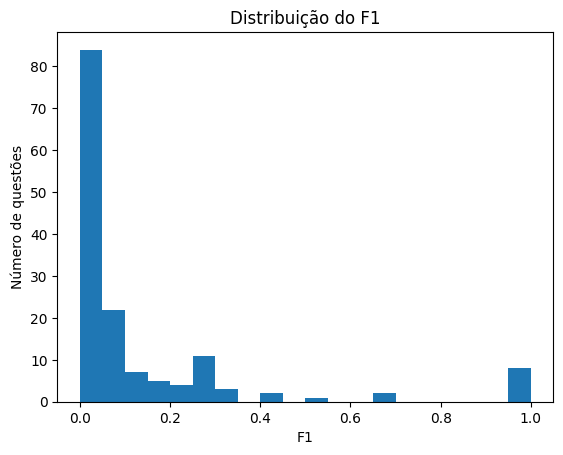

In [ ]:
plt.hist(f1s, bins=20)
plt.title("Distribuição do F1")
plt.xlabel("F1")
plt.ylabel("Número de questões")
plt.show()

#### Precisão x Recall

No geral, notei que os resultados possuem maior métrica de Recall e baixa métrica de precisão. Isso demonstra que o modelo gera muitas palavras, porém, de forma desnecessária.

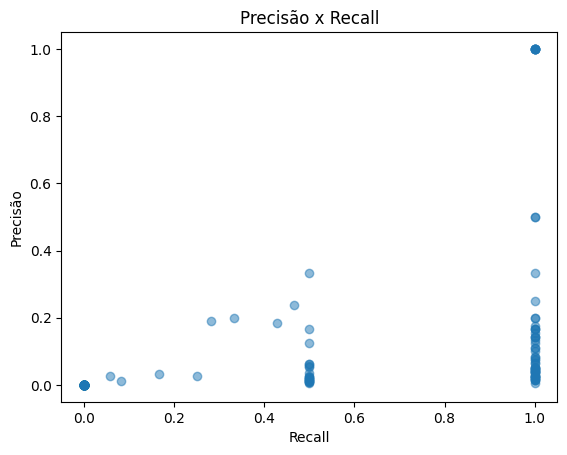

In [ ]:
plt.scatter(recalls, precisions, alpha=0.5)
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Precisão x Recall")
plt.show()

#### Análise mais detalhada das respostas

Podemos notar que alguns dos contextos não foram suficientes (o modelo retorna isso na resposta).

Além disso, algo que comentei anteriormente, sobre o alto recall (e baixa precisão), aqui podemos notar melhor. Há diversas perguntas que o modelo discorre longamente e a resposta esperada é simples e direta.

In [ ]:
# Seleciona 3 casos com F1=0
bad_cases = list(rag_results["f1_zero"].values())[:3]

# Seleciona 3 casos com F1>0
good_cases = list(rag_results["f1_positive"].values())[:3]

for case in bad_cases + good_cases:
  print("="*60)
  print("Question:", case["question"])
  print("Gold:", case["gold"])
  print("Prediction:", case["prediction"])
  print("F1:", case["f1"], "Precision:", case["precision"], "Recall:", case["recall"])
  print("Chunks usados:", 3)

Question: How old was Messe when the First World War started?
Gold: 30 years
Prediction: I don’t have enough information to determine Messe’s age. The provided excerpt discusses World War II dates and events but does not mention any person named Messe or provide any birth year or age data. If you have additional context or a specific source that mentions Messe, share it and I can calculate the age based on the starting date of the war.
F1: 0 Precision: 0 Recall: 0
Chunks usados: 3
Question: What is the capacity of the stadium where Brunt returned to action after a torn ACL?
Gold: 26,688
Prediction: 83,489
F1: 0 Precision: 0 Recall: 0
Chunks usados: 3
Question: Which battle Wilhelm Müller fought in while in the Prussian army had the highest casualty?
Gold: Kulm
Prediction: Based on the provided information, Wilhelm Müller fought in the Battle of Bautzen (20–21 May 1813) while in the Prussian army. The excerpt mentions that the Battle of Bautzen involved Prussians under Gebhard von Blüch

#### Avaliando por tipo de resposta

Verifiquei qual tipo de resposta meu RAG consegue melhor resultado.

In [ ]:
def evaluate_by_type(results_dict):
  """
    Verificação das métricas para cada tipo de resposta
  """
  metrics = defaultdict(list)

  for group in results_dict.values():
      for case in group.values():
          metrics[case["answer_type"]].append(case)

  report = {}
  for ans_type, cases in metrics.items():
      f1s = [c["f1"] for c in cases]
      precs = [c["precision"] for c in cases]
      recs = [c["recall"] for c in cases]

      report[ans_type] = {
          "n": len(cases),
          "avg_f1": sum(f1s) / len(f1s) if f1s else 0,
          "avg_precision": sum(precs) / len(precs) if precs else 0,
          "avg_recall": sum(recs) / len(recs) if recs else 0
      }
  return report

No geral, o modelo consegue melhor resultado com o tipo span (trecho contínuo), pois possuí maior precisão e bom recall.

In [ ]:
report = evaluate_by_type(rag_results)
for t, stats in report.items():
    print(f"\nTipo: {t}")
    print(f" Casos: {stats['n']}")
    print(f" F1 médio: {stats['avg_f1']:.2f}")
    print(f" Precisão média: {stats['avg_precision']:.2f}")
    print(f" Recall médio: {stats['avg_recall']:.2f}")


Tipo: value
 Casos: 42
 F1 médio: 0.06
 Precisão média: 0.03
 Recall médio: 0.46

Tipo: span
 Casos: 97
 F1 médio: 0.17
 Precisão média: 0.14
 Recall médio: 0.46

Tipo: binary
 Casos: 10
 F1 médio: 0.06
 Precisão média: 0.03
 Recall médio: 0.90


---